<a href="https://colab.research.google.com/github/michalshavitNYU/Waves/blob/main/Phase4_multifrequency_fft_wilton_ripple_Codex_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install kfac_jax==0.0.7

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.0/161.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.5/313.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>

In [ ]:
import sys
import jax
import jax.numpy as jnp

import numpy as np
import optax

import abc

from jax import random, vjp, vmap
from jax.tree_util import tree_map
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.io import savemat
from scipy.interpolate import interp1d
from pathlib import Path
import pickle

In [ ]:
import kfac_jax

In [ ]:
from kfac_jax import curvature_estimator
from kfac_jax import curvature_blocks
from kfac_jax import layers_and_loss_tags
from kfac_jax import loss_functions as kfac_loss_functions
from kfac_jax import optimizer as kfac_optim

In [ ]:
import os
import requests

from jax import random
from jax.tree_util import tree_map

In [ ]:
# change JAX to double precision
jax.config.update('jax_enable_x64', True)

# define the root path
rootdir = Path('/content/drive').joinpath('MyDrive')

# Customized function for collocation point arrangement

In [ ]:
import scipy
import jax.scipy as jsp

def gaussian1D_smooth(f, sig, wid):
    '''
    :param f: equally spaced 1D position matrix  (N, 1)
    :param sig: stan. devi of gaussian filter (1, ) or scalor
    :param wid: wid of the filter matrix (1, ) or scalor integer
    '''
    wid = jnp.int32(wid)
    xg = jnp.linspace(-sig, sig, wid)
    window = jsp.stats.norm.pdf(xg)
    win_n = window / jnp.sum(window)
    f_smooth = scipy.signal.convolve(f[:, 0], win_n, mode='same')[:, None] #f[:, 0] selects the first (and only) column of f, turning it into a 1D array of shape (N,).
    return f_smooth


# sample the data based on a given probability distribution
def colloc1D_set(key, x, f, Ns):
    '''
    :param x: 1-D position array (N, 1)
    :param f: 1-D distribution array (N, 1)
    :param Ns: number of points to sample
    '''
    # remove last element in each direction
    xc = x[0:-1, :]
    fc = f[0:-1, :]
    dx = xc[1] - xc[0]
    seq = jnp.arange(fc.shape[0] + 1)
    # generate key for random variables
    keys = jax.random.split(key, num=2)

    # obtain the cumulative sum of the z value
    b = jnp.hstack([0., jnp.cumsum(fc)])
    # obtain the random variable
    c = jax.random.uniform(keys[0], [Ns]) * b[-1]
    # generate the index position of each collocation point following the distribution
    # (using the interpolate the index of grid where each random variable stands)
    posi_intp = jnp.interp(c, b, seq)
    # round the result to guarantee that the index position is integer
    posi = jnp.int32(jnp.floor(posi_intp))
    # obtain the real position of each collocation point
    px = xc[posi, :]
    # generate a random fraction for each collocation point
    posi_add = jax.random.uniform(keys[1], [c.shape[0], 1])
    # add the random fraction to the position of each collocation points
    x_col = px + posi_add * dx

    return x_col


# Weight initialization and network architecture

In [ ]:
# ============================================================
# Initialize one MLP
# Format: list of [W, b]
# ============================================================

def init_MLP(parent_key, layer_widths):
    params = []
    keys = random.split(parent_key, num=len(layer_widths) - 1)

    for in_dim, out_dim, key in zip(layer_widths[:-1], layer_widths[1:], keys):
        weight_key, bias_key = random.split(key)

        xavier_stddev = jnp.sqrt(2.0 / (in_dim + out_dim))

        W = random.truncated_normal(
            weight_key, -2.0, 2.0, shape=(in_dim, out_dim)
        ) * xavier_stddev

        b = random.truncated_normal(
            bias_key, -2.0, 2.0, shape=(out_dim,)
        ) * xavier_stddev

        params.append([W, b])

    return params


# ============================================================
# Initialize all networks and free parameters
# ============================================================

def stwv_init_MLP(parent_key, n_hl, n_unit):
    """
    Returns:
        params = [net1, net2, net3, beta_mod, lamb_mod]
    """

    layers = [1] + n_hl * [n_unit] + [1]

    _, key1, key2, key3 = random.split(parent_key, 4)

    net1 = init_MLP(key1, layers)
    net2 = init_MLP(key2, layers)
    net3 = init_MLP(key3, layers)

    beta_mod = jnp.array([0.0], dtype=jnp.float64)
    lamb_mod = jnp.array([0.0], dtype=jnp.float64)

    params = [net1, net2, net3, beta_mod, lamb_mod]

    return params


parent_key = random.PRNGKey(0)

params = stwv_init_MLP(
    parent_key=parent_key,
    n_hl=3,
    n_unit=30,
)

In [ ]:
import urllib.parse

# ============================================================
# Choose stage-1 weights file
# ============================================================

# Stage-1 speed and surface tension for the checkpoint loaded below. These two
# numbers and the checkpoint must come from the SAME run: params below is a
# fresh network (lamb_mod = 0), so the training speed is exactly lamb0 = lamb1,
# with no tanh correction to absorb a mismatch. Verified on the Waves-repo
# checkpoint StokesWave_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl:
#
#     lamb = 1.167786478283629  ->  rms(e1) = 1.3e-03   (stage-1 run's CENTRE)
#     lamb = 1.168786478283629  ->  rms(e1) = 2.8e-09   (what it CONVERGED to)
#
# The centre is what gets typed by mistake; the converged value is what names
# the file. The baseline-check cell recomputes this from whatever actually
# loads -- trust that over this comment.
lamb1 = 1.168786478283629
beta1 = 0.4980
g = 1.0

# "github" first is the safe default: a second-stage run saves its own params
# under this same naming scheme, so a stale local file can shadow the stage-1
# solution and load an untrained network as the surface.
LOAD_FROM = "github"          # "github" or "local"

ExpName = f"StokesWave_lamd={lamb1:.4f}_beta={beta1:.4f}_g={g:.1f}"
local_weights_path = str(rootdir.joinpath(ExpName + "_weights.pkl"))

# Derived from ExpName so the two sources cannot drift to different runs.
github_weights_url = (
    "https://raw.githubusercontent.com/michalshavitNYU/Waves/main/"
    + urllib.parse.quote(ExpName + "_weights.pkl", safe="")
)
print("expecting checkpoint:", ExpName + "_weights.pkl")


# ============================================================
# Load previous stage-1 parameters
# ============================================================

def _load_local(path):
    if path is None or not os.path.exists(path):
        print(f"   local file not found: {path}")
        return None
    with open(path, "rb") as f:
        p = pickle.load(f)
    print(f"✅ Loaded params0 from local file:\n   {path}")
    return p


def _load_github(url):
    if url is None:
        return None
    r = requests.get(url, timeout=60)
    if r.status_code != 200:
        print(f"   GitHub returned {r.status_code} for\n   {url}")
        return None
    with open("downloaded_stage1_weights.pkl", "wb") as f:
        f.write(r.content)
    with open("downloaded_stage1_weights.pkl", "rb") as f:
        p = pickle.load(f)
    print(f"✅ Downloaded and loaded params0 from GitHub:\n   {url}")
    return p


def load_stage1_params(weights_path=None, github_url=None, prefer="github"):
    order = ["github", "local"] if prefer == "github" else ["local", "github"]
    params0 = None
    for src in order:
        print(f"trying {src} ...")
        params0 = _load_github(github_url) if src == "github" else _load_local(weights_path)
        if params0 is not None:
            break

    if params0 is None:
        raise FileNotFoundError(
            "Could not load params0 from GitHub or the local file.\n"
            f"  url  : {github_url}\n  local: {weights_path}\n"
            "Check that lamb1/beta1 name a checkpoint that exists."
        )

    # old format: [net1, net2, net3, lamb_mod] -> new: [..., beta_mod, lamb_mod]
    if len(params0) == 4:
        print("⚠️ Old format detected: [net1, net2, net3, lamb_mod]. Adding beta_mod = 0.")
        params0 = params0[:3] + [jnp.array([0.0], dtype=jnp.float64), params0[3]]

    print("\nFinal params0:")
    print("len =", len(params0))
    print("beta_mod =", params0[3])
    print("lamb_mod =", params0[4])
    return params0


params0 = load_stage1_params(
    weights_path=local_weights_path,
    github_url=github_weights_url,
    prefer=LOAD_FROM,
)

# Is this actually a trained stage-1 solution, or a second-stage params dump?
_tanh_lamb = float(jnp.tanh(params0[-1])[0])
_tanh_beta = float(jnp.tanh(params0[-2])[0])
print(f"\nstage-1 tanh(lamb_mod) = {_tanh_lamb:+.10f}")
print(f"stage-1 tanh(beta_mod) = {_tanh_beta:+.10f}")

if float(params0[-2][0]) == 0.0 and abs(_tanh_lamb) < 1e-2:
    print(
        "\n\u26a0\ufe0f  beta_mod is exactly 0 and lamb_mod is ~0: this looks like an\n"
        "    UNTRAINED network, i.e. a second-stage params dump rather than a\n"
        "    stage-1 solution. Expect t2 ~ 0.05 instead of reaching ~1."
    )
elif abs(_tanh_lamb) > 0.999:
    print(
        "\n\u26a0\ufe0f  stage-1 lamb_mod is saturated: that run hit its \u00b1eta bound, so its\n"
        "    converged speed sits one full eta away from the centre it was given."
    )

expecting checkpoint: StokesWave_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl
trying github ...
✅ Downloaded and loaded params0 from GitHub:
   https://raw.githubusercontent.com/michalshavitNYU/Waves/main/StokesWave_lamd%3D1.1688_beta%3D0.4980_g%3D1.0_weights.pkl

Final params0:
len = 5
beta_mod = [-8.38131234]
lamb_mod = [11.74643227]

stage-1 tanh(lamb_mod) = +0.9999999999
stage-1 tanh(beta_mod) = -0.9999998950

⚠️  stage-1 lamb_mod is saturated: that run hit its ±eta bound, so its
    converged speed sits one full eta away from the centre it was given.


In [ ]:
%%script false --no-raise-error
import urllib.parse

# ============================================================
# Choose stage-1 weights file
# ============================================================

# Stage-1 speed and surface tension for the checkpoint loaded below.
#
# These two numbers and the checkpoint have to come from the SAME run. Because
# params below is a fresh network (lamb_mod = 0), the training speed is exactly
# lamb0 = lamb1 -- there is no tanh correction to absorb a mismatch, so an error
# here goes straight into the residual. Measured on the Waves-repo checkpoint
# StokesWave_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl:
#
#     lamb = 1.167786478283629  ->  rms(e1) = 1.3e-03
#     lamb = 1.168786478283629  ->  rms(e1) = 2.8e-09   (least-squares optimum)
#
# The baseline-check cell after the problem setup recomputes this from whatever
# checkpoint actually loads and prints the speed to use. Trust that over this
# comment: if the two disagree, the file being loaded is not the one these
# numbers came from.
lamb1 = 1.167786478283629
beta1 = 0.4980
g = 1.0

ExpName = f"StokesWave_lamd={lamb1:.4f}_beta={beta1:.4f}_g={g:.1f}"

local_weights_path = str(rootdir.joinpath(ExpName + "_weights.pkl"))

# Derived from ExpName so the remote fallback cannot silently drift to a
# different run than the local path -- that is how a 1.1688 checkpoint ends up
# being scored at 1.1678.
github_weights_url = (
    "https://raw.githubusercontent.com/michalshavitNYU/Waves/main/"
    + urllib.parse.quote(ExpName + "_weights.pkl", safe="")
)
print("expecting checkpoint:", ExpName + "_weights.pkl")


# github_weights_url = (
#     "https://raw.githubusercontent.com/michalshavitNYU/Waves/main/"
#     "StokesWave_lamd%3D1.1668_beta%3D0.5000_g%3D1.0_weights.pkl"
# )


# ============================================================
# Load previous stage-1 parameters
# ============================================================

def load_stage1_params(weights_path=None, github_url=None):
    params0 = None

    # Try local file first
    if weights_path is not None and os.path.exists(weights_path):
        with open(weights_path, "rb") as f:
            params0 = pickle.load(f)

        print(f"✅ Loaded params0 from local file:\n{weights_path}")

    # Try GitHub if local loading failed
    if params0 is None and github_url is not None:
        print("Trying GitHub URL:")
        print(github_url)

        response = requests.get(github_url)

        if response.status_code == 200:
            tmp_path = "downloaded_stage1_weights.pkl"

            with open(tmp_path, "wb") as f:
                f.write(response.content)

            with open(tmp_path, "rb") as f:
                params0 = pickle.load(f)

            print("✅ Downloaded and loaded params0 from GitHub.")

        else:
            raise RuntimeError(
                f"GitHub download failed with status code {response.status_code}"
            )

    if params0 is None:
        raise FileNotFoundError("Could not load params0 from local file or GitHub.")

    # Backward compatibility:
    # old format: [net1, net2, net3, lamb_mod]
    # new format: [net1, net2, net3, beta_mod, lamb_mod]
    if len(params0) == 4:
        print("⚠️ Old format detected: [net1, net2, net3, lamb_mod].")
        print("Adding beta_mod = 0.")

        beta_mod = jnp.array([0.0], dtype=jnp.float64)
        params0 = params0[:3] + [beta_mod, params0[3]]

    print("\nFinal params0:")
    print("len =", len(params0))
    print("beta_mod =", params0[3])
    print("lamb_mod =", params0[4])

    return params0


params0 = load_stage1_params(
    weights_path=local_weights_path,
    github_url=github_weights_url,
)

# params0[-1] / params0[-2] are the stage-1 lamb_mod / beta_mod. Saturated
# values mean that run pushed its speed to the edge of its own +/- eta window.
_tanh_lamb = float(jnp.tanh(params0[-1])[0])
_tanh_beta = float(jnp.tanh(params0[-2])[0])
print(f"\nstage-1 tanh(lamb_mod) = {_tanh_lamb:+.10f}")
print(f"stage-1 tanh(beta_mod) = {_tanh_beta:+.10f}")
if abs(_tanh_lamb) > 0.999:
    print(
        "\u26a0\ufe0f  stage-1 lamb_mod is saturated: that run hit its \u00b1eta1 bound, so its\n"
        "    converged speed sits one full eta1 away from the centre it was given.\n"
        "    If lamb1 above was copied from that centre it is short by exactly eta1."
    )


In [ ]:
def linfun(x):
    return x

# define sech function
def sech(z):
    return 1 / jnp.cosh(z)


def network_core(params, H):
    # separate the first, hidden and last layers
    first, *hidden, last = params
    # calculate the first layers output with right scale
    H = jnp.tanh(jnp.dot(H, first[0]) + first[1])
    # calculate the middle layers output
    for layer in hidden:
        H = jnp.tanh(jnp.dot(H, layer[0]) + layer[1])
    # no activation function for last layer
    var = jnp.dot(H, last[0]) + last[1]
    return var


# # define the basic formation of neural network
# def neural_net_even(params, x, limit):
#     '''
#     :param params: weights and biases
#     :param limit: characteristic scale for normalization [matrix with shape [2, m]]
#     :return: neural network output [matrix with shape [N, n]]; n is number of outputs)
#     '''
#     pd = limit[0]  # half period in x and length in y
#     # normalize the input
#     th = x / pd
#     # double the variable in r direction
#     H = jnp.cos(jnp.pi * th) # even function with respect to x = 0
#     # calculate the output for all networks
#     var0 = network_core(params[0], H)
#     var1 = network_core(params[1], H) * jnp.sin(jnp.pi*th)
#     var2 = network_core(params[2], H)
#     return jnp.hstack([var0, var1, var2])  #another option: return var0, var1

#dfq is dominant freq of residue
def network_fourier(params, H, dfq):
    # separate the first, hidden and last layers
    first, *hidden, last = params
    # calculate the first layers output with right scale
    H = jnp.sin(jnp.dot(H, first[0]*dfq) + first[1])
    # calculate the middle layers output
    for layer in hidden:
        H = jnp.sin(jnp.dot(H, layer[0]) + layer[1]) #check with yongji if should be H = jnp.tanh(jnp.dot(H, layer[0]) + layer[1])
    # no activation function for last layer
    var = jnp.dot(H, last[0]) + last[1]
    return var


# epsilonp scales the correction network. At exactly 0 the correction term
# drops out of predf, so its weights have identically zero gradient and this
# stage trains nothing but lamb (and beta, if eta_beta != 0). Keep 0 for the
# baseline residual check, then set it nonzero to actually train the correction.
epsilonp = 1e-10 #1e-12 #1e-8 #0. #10**(-1) #1e-11
sclp = 0.27 #sclp is scl from previous training
dfq = 144 #50 #150. # need to test the best value of it, dominant freq of residue



# set the size of domain #this is a duplicate for now, need to clean later
pd = jnp.pi
scl = 0.27
lmt = jnp.array([pd, scl])


def neural_net_fourier(params, x, limit, dfq):
    '''
    :param params: weights and biases
    :param limit: characteristic scale for normalization [matrix with shape [2, m]]
    :return: neural network output [matrix with shape [N, n]]; n is number of outputs)
    '''
    pd = limit[0]  # half period in x and length in y
    # normalize the input
    th = x / pd
    # double the variable in r direction
    H = jnp.cos(jnp.pi * th) # even function with respect to x = 0
    # calculate the output for all networks
    var0 = network_fourier(params[0], H, dfq)
    var1 = network_fourier(params[1], H, dfq) * jnp.sin(jnp.pi*th) ##if doesnt work check if needs to be fourier dfq
    var2 = network_fourier(params[2], H, dfq)
    return jnp.hstack([var0, var1, var2])  #another option: return var0, var1


    # define the basic formation of neural network
def neural_net_even(params, x, limit):
    '''
    :param params: weights and biases
    :param limit: characteristic scale for normalization [matrix with shape [2, m]]
    :return: neural network output [matrix with shape [N, n]]; n is number of outputs)
    '''
    pd = limit[0]  # half period in x and length in y
    # normalize the input
    th = x / pd
    # double the variable in r direction
    H = jnp.cos(jnp.pi * th) # even function with respect to x = 0
    # calculate the output for all networks
    var0 = network_core(params[0], H)
    var1 = network_core(params[1], H) * jnp.sin(jnp.pi*th)
    var2 = network_core(params[2], H)
    return jnp.hstack([var0, var1, var2])  #another option: return var0, var1

# for second stage training we define the base function from pevious training

def prepare_from_stage1(params,limit):
    def y_p(x):
        return sclp * neural_net_even(params[0:3], x, limit)
    return y_p


y_p = prepare_from_stage1(params0,lmt) # previous trained params0



def stwv_pred_create(limit):
    '''
    :param limit: domain size of the input
    :return: function of the solution (a callable)
    '''
    pd, scl = limit  # half period in x and length in y
    # high-level architecture for IPM solution
    def f(params, x):
        # calculate the raw network output
        y =  y_p(x) + epsilonp * neural_net_fourier(params[0:3], x, limit, dfq) #was params[0] #maybe dont need to multiply by scl?
        #y = neural_net_even(params[0:3], x, limit) #was params[0] #maybe dont need to multiply by scl?
        return y
    return f



def stwv_pred_create_test(limit, m,n):
    '''
    :param limit: domain size of the input
    :return: function of the solution (a callable)
    '''
    pd, scl = limit  # half period in x and length in y
    # high-level architecture for IPM solution
    def f(params, x):
        # calculate the raw network output
        y = scl * (jnp.cos(m*x) + jnp.cos(n*x)) + neural_net_even(params[0:3], x, limit)*0  #was params[0]
        return y
    return f


In [ ]:
# ============================================================
# Optional helper: estimate dominant residual frequency.
# Run this only after stwv_gov_eqn and hptrans are defined.
# Use kmax large enough to see the Phase 4 residual band near k ~= 1000.
# ============================================================

def estimate_dfq_epsilonp(base_func, lamb, beta, N=4096, kmax=1600, plot=True):
    x = jnp.linspace(-jnp.pi, jnp.pi, N, endpoint=False)[:, None]
    r = np.asarray(stwv_gov_eqn(base_func, x, lamb, beta)[:, 0])
    r = r - r.mean()

    amp = np.abs(np.fft.rfft(r))
    amp[:3] = 0
    amp[kmax + 1:] = 0

    k0 = int(np.argmax(amp))
    rms = float(np.sqrt(np.mean(r**2)))
    symbol = abs(beta**2 * k0**2 - lamb**2 * k0 + g)
    eps = np.clip(5.0 * rms / max(symbol, 1.0), 1e-13, 1e-8)

    if plot:
        kk = np.arange(len(amp))
        plt.figure(figsize=(8, 4), dpi=120)
        plt.semilogy(kk[:kmax + 1], amp[:kmax + 1], 'k-')
        plt.axvline(k0, color='r', linestyle='--', label=f'dominant k = {k0}')
        plt.xlabel('Fourier mode k')
        plt.ylabel('|FFT residual e1|')
        plt.legend()
        plt.show()

    return float(k0), float(eps), amp


# numiercal Periodic Hilbert Transform

In [ ]:
"""High-precision numerical calculation of Hilbert *transform*"""


def hilb_bd_detect(x, xn, n):
    # detect the position of data in xn that is next to x
    vn0 = xn - x
    tn = jnp.tan(vn0 / 2)
    # convert the vn to the new range from -pi to pi
    vn = 2 * jnp.arctan(tn)   # very important step
    # compute the p variable based on the new vn
    pn = jnp.sin(vn / 2)
    # find the least positive and most negative points
    tn0 = tn - (tn > -1e-16) * jnp.inf
    tn1 = tn + (tn < 1e-16) * jnp.inf
    idxb0 = jnp.argmin(-tn0)
    idxb1 = jnp.argmin(tn1)
    # distance of those point withe respect zero
    hp0 = -pn[idxb0]
    hp1 = pn[idxb1]
    hpm = (hp0 + hp1)/2
    # prepare the nodes for inner domain integration with respect to vn
    p_front = -jnp.arange(n, 0, -2) * hpm / n
    p_rear = jnp.arange(1, n + 1, 2) * hpm / n
    p_inner = jnp.hstack([p_front, p_rear])
    # convert the node back to original coordinate
    x_in = jnp.arcsin(p_inner) * 2 + x

    # detect the boundary for the closer region
    tnc0 = tn - (tn >= -15 * hpm) * jnp.inf
    tnc1 = tn + (tn <= 15 * hpm) * jnp.inf
    idxc0 = jnp.argmin(-tnc0)
    idxc1 = jnp.argmin(tnc1)
    # compute the tn value for the closest point
    tn_cl = jnp.array([tn[idxc0], tn[idxc1]])
    # compute the pn value for the closest point
    pn0_cl = pn[idxc0]
    pn1_cl = pn[idxc1]
    # compute the qn value for the closest point to pn_bd[0]
    qn0_cl = jnp.flip(jnp.log(-pn0_cl))
    qn1_cl = jnp.log(pn1_cl)
    # compute the qn value for the inner point
    qn0_bd = jnp.flip(jnp.log(hpm))
    qn1_bd = jnp.log(hpm)
    # create the node point in qn for the closer region
    qn0 = jnp.linspace(qn0_bd, qn0_cl, 8)
    qn1 = jnp.linspace(qn1_bd, qn1_cl, 8)
    return x_in, qn0, qn1, tn_cl


def hilbtrans_close(x, q1n, q2n, func, params_c):
    '''
    hilbert transform of one single output using non-uniform sampling
    based on Bilato's paper with O(h^2) accuracy
    '''
    # unroll the params
    ni, wi = params_c
    # compute the bound for each gaussian quadrature (GQ) integral
    a1 = q1n[0:-1]
    b1 = q1n[1:]
    a2 = q2n[0:-1]
    b2 = q2n[1:]
    # normalize the gaussian quadrature range
    q1i = (b1 - a1) / 2 * ni + (a1 + b1) / 2
    q2i = (b2 - a2) / 2 * ni + (a2 + b2) / 2
    # compute the corresponding x value for the GQ interpolation point
    x1i = 2 * jnp.arcsin(-jnp.exp(q1i))
    x2i = 2 * jnp.arcsin(jnp.exp(q2i))
    x1i = x1i + x
    x2i = x2i + x
    # calculate the integrand of Gaussian quadrature
    f1 = vmap(func, in_axes=0)(x1i[:, :, None])[:, :, 0]
    f2 = -vmap(func, in_axes=0)(x2i[:, :, None])[:, :, 0]
    # calculate using Gaussian Quadrature
    close1 = (b1 - a1) / 2 * jnp.matmul(wi, f1)[0]
    close2 = (b2 - a2) / 2 * jnp.matmul(wi, f2)[0]
    close_all = jnp.hstack((close1, close2))
    # sum all the sub-integral
    closesum = jnp.sum(close_all)[None]
    return closesum


def hilbInt_outer(x, tn_cl, params_o):
    '''
    hilbert transform of one single output using non-uniform sampling
    based on Bilato's paper with O(h^2) accuracy
    '''
    # unroll the params
    xn, a, b, xi, fxi, ni, wi = params_o
    # detect the position of data in xn that is next to x
    vn = xn - x
    tn = jnp.tan(vn / 2)
    sg = (tn < tn_cl[0]-2e-16) | (tn >= tn_cl[1])
    # calculate the integrand of Gaussian quadrature
    fh = fxi / jnp.tan((x - xi) / 2) / 2
    # calculate using Gaussian Quadrature
    outer = (b-a) / 2 * jnp.matmul(wi, fh)[0] * sg[0:-1]
    outsum = jnp.sum(outer)[None]
    return outsum


def hilb_perid_cubic(xn):
    '''
    hilbert transform of multiple outputs at any positions
    within the range of sampling points
    params func: function with respect to z (not x)
    '''
    # order of the method
    n = 3
    # flatten the sampling point (for output shape)
    xn = xn.flatten()
    # set the Gaussian Quadrature nodes  (order 9)
    e1 = jnp.array(1 / 3 * jnp.sqrt(5 - 2 * jnp.sqrt(10 / 7)))
    e2 = jnp.array(1 / 3 * jnp.sqrt(5 + 2 * jnp.sqrt(10 / 7)))
    # set the Gaussian Quadrature weights (order 9)
    c1 = jnp.array((322 - 13 * jnp.sqrt(70)) / 900)
    c2 = jnp.array((322 + 13 * jnp.sqrt(70)) / 900)
    c3 = jnp.array(128 / 225)
    # group and match the weights and nodes
    ni = jnp.vstack([-e2, -e1, 0, e1, e2])
    wi = jnp.hstack([c1, c2, c3, c2, c1])[None, :]
    # prepare the outer domain integration
    a = xn[0:-1]
    b = xn[1:]
    # change of variables
    xi = (b - a) / 2 * ni + (a + b) / 2

    def hpfunc(x, func):
        # obtain the position info for the inner and closer domain
        x_in, q1n, q2n, tn_cl = vmap(hilb_bd_detect, in_axes=(0, None, None))(x, xn, n)
        # prepare the nodes for inner domain integration
        f_in = vmap(func, in_axes=0)(x_in[:, :, None])[:, :, 0]
        # coefficient based on LG interpolation
        c_in = jnp.array([1/4, 9/4, -9/4, -1/4])
        # calculate the inner domain integration
        Iinner = jnp.sum(c_in * f_in, axis=1)[:, None]

        # group parameters required for close domain calculation
        params_c = [ni, wi]
        # calculation the close domain integration
        Iclose = vmap(hilbtrans_close, in_axes=(0, 0, 0, None, None))(x, q1n, q2n, func, params_c)

        # calculate the outer domain integration
        fxi = vmap(func, in_axes=0)(xi[:, :, None])[:, :, 0]
        params_o = [xn, a, b, xi, fxi, ni, wi]
        # calculation the outer domain integration
        Iouter = vmap(hilbInt_outer, in_axes=(0, 0, None))(x, tn_cl, params_o)
        # Iouter = hilbInt_outer(x[0], tn_cl[0], params_o)
        # sum up the components to the final expression
        hfx = (Iinner + Iclose + Iouter) / jnp.pi
        return hfx

    return hpfunc


# ============================================================
# Phase 2 Hilbert transform: spectral periodic transform on a
# uniform full-period grid. Every residual call using this hptrans
# must use x = linspace(-pi, pi, N, endpoint=False)[:, None].
# Convention: H[cos(kx)] = sin(kx), H[sin(kx)] = -cos(kx).
# ============================================================

def hilb_perid_fft_uniform():
    def hpfunc(x, func):
        f = func(x)
        if f.ndim == 1:
            f = f[:, None]

        n = f.shape[0]
        F = jnp.fft.fft(f, axis=0)
        k = jnp.fft.fftfreq(n) * n
        multiplier = -1j * jnp.sign(k)
        multiplier = jnp.where((n % 2 == 0) & (jnp.arange(n) == n // 2), 0.0, multiplier)
        multiplier = multiplier[:, None]
        return jnp.fft.ifft(multiplier * F, axis=0).real

    return hpfunc


def hilbert_fourier_test_uniform(hptrans, modes=(1, 2, 3, 10, 25, 50, 100, 150, 200, 300), N_test=4096):
    x = jnp.linspace(-jnp.pi, jnp.pi, N_test, endpoint=False)[:, None]
    print(f"{'k':>6} {'cos rms':>12} {'cos max':>12} {'sin rms':>12} {'sin max':>12}")
    print('-' * 58)

    for k in modes:
        f_cos = lambda z, k=k: jnp.cos(k * z)
        f_sin = lambda z, k=k: jnp.sin(k * z)

        err_cos = hptrans(x, f_cos) - jnp.sin(k * x)
        err_sin = hptrans(x, f_sin) + jnp.cos(k * x)

        print(
            f"{k:6d} "
            f"{float(jnp.sqrt(jnp.mean(err_cos**2))):12.3e} "
            f"{float(jnp.max(jnp.abs(err_cos))):12.3e} "
            f"{float(jnp.sqrt(jnp.mean(err_sin**2))):12.3e} "
            f"{float(jnp.max(jnp.abs(err_sin))):12.3e}"
        )


# Governing equation and Loss function

In [ ]:
"""
Low-level functions for Stokes-wave PINN training in JAX.

Assumptions:
- jax, jax.numpy as jnp, vjp, vmap, and kfac_loss_functions are imported.
- hptrans(x, f) implements the periodic Hilbert transform:
    hptrans(x, f) ~ H[f(x)]
- Global constants: g (gravity), beta (surface tension),
  epsilon, scl, m, (optionally n) are defined elsewhere.
"""

# -------------------------------------------------------------------
# Basic loss utilities
# -------------------------------------------------------------------

def ms_error(diff):
    """
    Mean squared error along axis=0.

    Parameters
    ----------
    diff : array, shape (N, k)
        Difference or residual values.

    Returns
    -------
    mse : array, shape (k,)
        Mean of squared entries over samples.
    """
    return jnp.mean(jnp.square(diff), axis=0)


def ms_bias(diff, weight):
    """
    Weighted sum of squared errors.

    Parameters
    ----------
    diff : array, shape (N, k)
        Residual values.
    weight : array, shape (N, k) or (N, 1)
        Quadrature weights (or general weights).

    Returns
    -------
    scalar : float
        Sum_i weight_i * diff_i^2
    """
    return jnp.sum(weight * jnp.square(diff))


# -------------------------------------------------------------------
# Autodiff helpers: vector-Jacobian products and gradient assembly
# -------------------------------------------------------------------

def vgmat(z, n_out, idx=None):
    """
    Build a selection matrix for vector-Jacobian products.

    This constructs a tensor 'mat' such that applying vjp(func, z)
    with 'mat[l, :, ii] = 1' picks out partial derivatives of output
    component 'ii'.

    Parameters
    ----------
    z : array, shape (N, d)
        Input points.
    n_out : int
        Number of output variables of func(z).
    idx : list[int] or None
        List of output indices to take gradients of.
        If None, uses range(n_out).

    Returns
    -------
    mat : array, shape (n_idx, N, n_out)
        Selection tensor for vjp.
    """
    if idx is None:
        idx = range(n_out)

    n_idx = len(idx)      # number of selected output components
    n_pt = z.shape[0]     # number of input points

    mat_shape = [n_idx, n_pt, n_out]
    mat = jnp.zeros(mat_shape)

    # For each selected output index, set the corresponding slice to 1
    for l, ii in zip(range(n_idx), idx):
        mat = mat.at[l, :, ii].set(1.0)

    return mat


def batch_mul(mat1, mat2):
    """
    Batched element-wise multiplication along first axis.

    Parameters
    ----------
    mat1 : array, shape (B, N, k)
    mat2 : array, shape (N, k)

    Returns
    -------
    mat_prod : array, shape (B, N, k)
        mat_prod[b] = mat1[b] * mat2 (element-wise).
    """
    prod = lambda x, y: jnp.multiply(x, y)
    mat_prod = vmap(prod, (0, None))
    return mat_prod(mat1, mat2)


def vectgrad(func, z):
    """
    Compute gradients of vector-valued func with respect to inputs z.

    Given func: R^d -> R^m and a batch of points z (N,d),
    returns both the flattened gradient and the function values.

    Parameters
    ----------
    func : callable
        Maps z -> array of shape (N, m).
    z : array, shape (N, d)
        Input batch.

    Returns
    -------
    grad_all : array, shape (N, d*m)
        Flattened gradient at each point.
    sol : array, shape (N, m)
        Function values func(z).
    """
    # Evaluate function and create vjp callable
    sol, vjp_fn = vjp(func, z)

    # Build selection tensor for each output component
    mat = vgmat(z, sol.shape[1])

    # vjp over the selection tensor (batched over output-index dimension)
    grad0 = vmap(vjp_fn, in_axes=0)(mat)[0]  # shape (n_idx, N, d)

    # Reorder axes -> (N, n_idx, d)
    grad_s = grad0.transpose(1, 0, 2)

    # Flatten over outputs and input dimensions -> (N, d * m)
    n_pd = z.shape[1] * sol.shape[1]
    grad_all = grad_s.reshape(z.shape[0], n_pd)

    return grad_all, sol


# -------------------------------------------------------------------
# Governing equations (Stokes travelling wave, Hilbert form)
# -------------------------------------------------------------------

def stwv_gov_eqn(func, x, lamb, beta):
    """
    Active Hilbert-form Stokes residual [e1, e2, e3].

    This slim version avoids unused high-order transforms in the training loss.
    """
    f_y = lambda z: func(z)[:, 0:1]
    f_tens1 = lambda z: func(z)[:, 1:2]
    f_tens2 = lambda z: func(z)[:, 2:3]

    y_x, y = vectgrad(f_y, x)
    f_yx = lambda z: vectgrad(f_y, z)[0]
    f_ysqx = lambda z: vectgrad(lambda w: f_y(w) ** 2, z)[0]

    Hy_x = hptrans(x, f_yx)
    Hysq_x = hptrans(x, f_ysqx)

    dtens1, tens1 = vectgrad(f_tens1, x)
    tens2 = f_tens2(x)
    Hdtens2 = hptrans(x, lambda z: vectgrad(f_tens2, z)[0])

    e1 = (
        -lamb**2 * Hy_x
        + g * y
        + g * 0.5 * Hysq_x
        + g * y * Hy_x
        + beta**2 * (-dtens1 + Hdtens2)
    )

    denom = jnp.sqrt(y_x**2 + (1.0 + Hy_x)**2)
    e2 = tens2 - (1.0 + Hy_x) / denom
    e3 = tens1 - y_x / denom

    return jnp.hstack([e1, e2, e3])


def stwv_deri_eqn(func, x, lamb, beta):
    """
    Compute the derivative residual e_d = ∂_x e1 for higher-accuracy diagnostics.

    Parameters
    ----------
    func : callable
        Neural network mapping x -> [y, t1, t2].
    x : array, shape (N, 1)
        Collocation points for derivative residual.
    lamb : float
        Wave speed λ.

    Returns
    -------
    e_d : array, shape (N, 1)
        Derivative residual of the dynamic equation.
    """
    # Extract fields
    f_y     = lambda z: func(z)[:, 0:1]
    f_tens1 = lambda z: func(z)[:, 1:2]
    f_tens2 = lambda z: func(z)[:, 2:3]

    # First derivative of y
    y_x, y = vectgrad(f_y, x)

    # Build derivative helper lambdas
    f_yx   = lambda z: vectgrad(f_y, z)[0]
    f_yxx  = lambda z: vectgrad(f_yx, z)[0]
    f_ysq  = lambda z: f_y(z) ** 2
    f_ysqx = lambda z: vectgrad(f_ysq, z)[0]
    f_ysqxx = lambda z: vectgrad(f_ysqx, z)[0]

    # Hilbert transforms of derivatives
    Hy_x  = hptrans(x, f_yx)
    Hy_xx = hptrans(x, f_yxx)
    Hysq_xx = hptrans(x, f_ysqxx)

    # Second derivatives for t1 and t2
    f_tens1_x  = lambda z: vectgrad(f_tens1, z)[0]
    f_tens1_xx = lambda z: vectgrad(f_tens1_x, z)[0]
    d2tens1    = f_tens1_xx(x)

    f_tens2_x  = lambda z: vectgrad(f_tens2, z)[0]
    f_tens2_xx = lambda z: vectgrad(f_tens2_x, z)[0]
    Hd2tens2   = hptrans(x, f_tens2_xx)

    # Derivative residual: ∂_x e1
    e_d = (
        -lamb**2 * Hy_xx
        + g * y_x
        + g * 0.5 * Hysq_xx
        + g * y_x * Hy_x
        + g * y * Hy_xx
        + (beta)**2 * (-d2tens1 + Hd2tens2)
    )

    # Note: you could also add derivative equations for e2,e3 if needed.
    return e_d


In [ ]:
def stwv_loss_scale(func, x, beta, boost=1.0, floor=0.2, ceil=100.0): #codex
    f_y = lambda z: func(z)[:, 0:1]
    f_t1 = lambda z: func(z)[:, 1:2]
    f_t2 = lambda z: func(z)[:, 2:3]

    y_x, _ = vectgrad(f_y, x)
    f_yx = lambda z: vectgrad(f_y, z)[0]
    f_yxx = lambda z: vectgrad(f_yx, z)[0]

    y_xx = f_yxx(x)
    Hy_x = hptrans(x, f_yx)
    Hy_xx = hptrans(x, f_yxx)

    dt1, _ = vectgrad(f_t1, x)
    Hdt2 = hptrans(x, lambda z: vectgrad(f_t2, z)[0])

    raw = (
        jnp.abs(y_x) + jnp.abs(Hy_x)
        + boost * (jnp.abs(y_xx) + jnp.abs(Hy_xx))
        + beta**2 * (jnp.abs(dt1) + jnp.abs(Hdt2))
    )

    scale = raw / (jnp.mean(raw) + 1e-30)
    return jax.lax.stop_gradient(jnp.clip(scale, floor, ceil))

In [ ]:
# # -------------------------------------------------------------------
# # Analytical test
# # -------------------------------------------------------------------
#     def stwv_lin_gcap_eqn(func, x, lamb, g, beta):
#     """
#     Minimal linear gravity–capillary equation:
#         e1 = -lambda^2 H[y_x] + g*y - beta*y_xx

#     Parameters
#     ----------
#     func : callable
#         func(z) returns array (N, 1) with y(z).
#     x : array, shape (N, 1)
#         Collocation points.
#     lamb : float
#         Wave speed parameter λ.
#     g : float
#         Gravity.
#     beta : float
#         Surface tension coefficient.

#     Returns
#     -------
#     e1 : array, shape (N, 1)
#         Residual of the linear PDE at each x.
#     """
#     # y(x)
#     f_y = lambda z: func(z)[:, 0:1]

#     # y_x and y
#     y_x, y = vectgrad(f_y, x)

#     # y_xx: derivative of y_x
#     f_yx = lambda z: vectgrad(f_y, z)[0]
#     y_xx, _ = vectgrad(f_yx, x)

#     # Hilbert transform H[y_x]
#     Hy_x = hptrans(x, f_yx)

#     # Linear PDE residual
#     e1 = -lamb**2 * Hy_x + g * y - beta * y_xx

#     return e1

In [ ]:
# -------------------------------------------------------------------
# Loss function factory
# -------------------------------------------------------------------

def loss_create(predf, cond, lamb0, beta0, lw, ew, train_df=False):
    """
    Create the PINN loss.

    Phase 2 default:
    - train on gradient-normalized main residual only;
    - optionally include derivative residual by setting train_df=True and ew=[1, weight_df].
    """
    def loss_fun(params, data):
        eta = data['eta']
        eta_beta = data['eta_beta']
        sym = data['sym']
        delta = data['delta']

        lref = loss_fun.ref
        eqn_weight = loss_fun.ew
        use_df = bool(loss_fun.train_df)

        data_weight = jnp.array([1.0, sym, 0.0, 0.0, 0.0])

        func = lambda z: predf(params, z)
        f_y = lambda z: func(z)[:, 0:1]
        f_yx = lambda z: vectgrad(f_y, z)[0]

        beta_raw = params[-2]
        lambda_raw = params[-1]
        lamb = lamb0 + eta * jnp.tanh(lambda_raw)
        beta = beta0 + eta_beta * jnp.tanh(beta_raw)

        x_nm, y_nm = cond['cond_nm']
        x_c, w_c = data['col']
        x_d, w_d = data['grad']
        x_s = data['smp']

        x_0 = jnp.array([[0.0]])
        x_pi = jnp.array([[jnp.pi]])
        x_mpi = jnp.array([[jnp.pi / (2 * m)]])

        y_nm_p = func(x_nm)[:, 0:1]
        y_0 = func(x_0)[:, 0:1]
        y_pi = func(x_pi)[:, 0:1]
        y_mpi = func(x_mpi)[:, 0:1]
        d2y_0 = vectgrad(f_yx, x_0)[0]

        f_c = stwv_gov_eqn(func, x_c, lamb, beta)
        scale_c = data['scale_c'] if 'scale_c' in data else stwv_loss_scale(y_p, x_c, beta, boost=1.0)
        f_c_loss = f_c / jnp.hstack([scale_c, scale_c, scale_c])

        if use_df:
            f_d = stwv_deri_eqn(func, x_d, lamb, beta)
            scale_d = data['scale_d'] if 'scale_d' in data else stwv_loss_scale(y_p, x_d, beta, boost=2.0)
            f_d_loss = f_d / scale_d

        norm_err = ms_error(jax.nn.relu(y_nm - y_nm_p))
        symm_err = ms_error(jax.nn.relu(delta - jnp.abs(y_0 - y_pi)))

        target_d2y0 = -(n * n * a_n + m * m * a_m)
        band_d2y0 = 7.0 * a_n**2
        wilt_err2 = ms_error(jax.nn.relu(jnp.abs(d2y_0 - target_d2y0) - band_d2y0))

        target_pi = scl + scl**2 / 4.0
        wilt_err3 = ms_error(jax.nn.relu(-y_pi - target_pi - epsilon))

        intfc = jnp.mean(func(x_s)[:, 0:1], axis=0)[:, None]
        mean_y = ms_error(intfc)

        data_err = jnp.hstack([norm_err, symm_err, wilt_err2, wilt_err3, mean_y])

        eqn_err_f = ms_bias(f_c_loss, w_c)
        if use_df:
            eqn_err_df = ms_bias(f_d_loss, w_d)
            eqn_err = jnp.hstack([eqn_err_f, eqn_err_df])
        else:
            eqn_err = jnp.hstack([eqn_err_f])

        kfac_loss_functions.register_squared_error_loss(
            jax.nn.relu(y_nm - y_nm_p),
            targets=jnp.zeros_like(y_0),
            weight=(data_weight[0] / y_0.size / lref)
        )

        kfac_loss_functions.register_squared_error_loss(
            jax.nn.relu(delta - jnp.abs(y_0 - y_pi)),
            targets=jnp.zeros_like(y_0),
            weight=(data_weight[1] / y_0.size / lref)
        )

        kfac_loss_functions.register_squared_error_loss(
            jax.nn.relu(jnp.abs(d2y_0 - target_d2y0) - band_d2y0),
            targets=jnp.zeros_like(d2y_0),
            weight=(data_weight[2] / d2y_0.size / lref)
        )

        kfac_loss_functions.register_squared_error_loss(
            jax.nn.relu(-y_pi - target_pi - epsilon),
            targets=jnp.zeros_like(y_pi),
            weight=(data_weight[3] / y_pi.size / lref)
        )

        kfac_loss_functions.register_squared_error_loss(
            intfc,
            targets=jnp.zeros_like(intfc),
            weight=(data_weight[4] / intfc.size / lref)
        )

        kfac_loss_functions.register_squared_error_loss(
            f_c_loss * jnp.sqrt(w_c),
            targets=jnp.zeros_like(f_c_loss),
            weight=(lw * eqn_weight[0] / lref)
        )

        if use_df:
            kfac_loss_functions.register_squared_error_loss(
                f_d_loss * jnp.sqrt(w_d),
                targets=jnp.zeros_like(f_d_loss),
                weight=(lw * eqn_weight[1] / lref)
            )

        loss_data = jnp.sum(data_err * data_weight)
        loss_eqn = jnp.sum(eqn_err * eqn_weight)
        loss = loss_data + lw * loss_eqn
        loss_n = loss / lref

        loss_info = jnp.hstack([
            jnp.array([loss, loss_data, loss_eqn]),
            data_err,
            eqn_err,
            lamb,
            beta
        ])

        return loss_n, loss_info

    loss_fun.ref = 1.0
    loss_fun.ew = ew
    loss_fun.train_df = train_df
    return loss_fun


In [ ]:
class KfacOptimizer(abc.ABC):
  """kfac_jax optimizer."""

  def __init__(self, loss_fn, **kwargs):

    # loss_fn = functools.partial(
    #     loss_fn,
    #     curvature_block_grouping=kwargs.pop("curvature_block_grouping"))

    self._value_and_grad_func = jax.value_and_grad(loss_fn, has_aux=True)

    self._norm_constraint = kwargs.pop("norm_constraint")
    self._curvature_block_type = kwargs.pop("curvature_block_type")

    learning_rate = kwargs.pop("learning_rate")
    momentum = kwargs.pop("momentum")
    damping = kwargs.pop("damping")
    self._initial_damping = kwargs.pop("initial_damping")
    self._min_damping = kwargs.pop("min_damping")

    if learning_rate is not None:
      self._learning_rate_schedule = optax.constant_schedule(learning_rate)
      self._use_adaptive_learning_rate = False
    else:
      self._learning_rate_schedule = None
      self._norm_constraint = None
      self._use_adaptive_learning_rate = True

    if momentum is not None:
      self._momentum_schedule = optax.constant_schedule(momentum)
      self._use_adaptive_momentum = False
    else:
      self._momentum_schedule = None
      self._norm_constraint = None
      self._use_adaptive_momentum = True

    if damping is not None:
      self._damping_schedule = optax.constant_schedule(damping)
      self._initial_damping = None
      self._min_damping = None
      self._use_adaptive_damping = False

    else:
      self._damping_schedule = None
      self._use_adaptive_damping = True

    self._extra_kwargs = kwargs

  def get_optimizer(self):
    """Returns the kfac_jax optimizer as defined using optimizer config."""

    # should pass these to the optimizer directly instead of doing these
    # module-level calls

    if self._curvature_block_type == "naive_full":
      curvature_estimator.set_default_tag_to_block_ctor(
          "generic", curvature_blocks.NaiveFull)

    else:
      raise ValueError(
          f"Unknown curvature block type: {self._curvature_block_type}.")

    self.optimizer = kfac_optim.Optimizer(
        self._value_and_grad_func,
        l2_reg=0.0,
        value_func_has_aux=True,
        use_adaptive_learning_rate=self._use_adaptive_learning_rate,
        use_adaptive_momentum=self._use_adaptive_momentum,
        use_adaptive_damping=self._use_adaptive_damping,
        initial_damping=self._initial_damping,
        min_damping=self._min_damping,
        norm_constraint=self._norm_constraint,
        learning_rate_schedule=self._learning_rate_schedule,
        momentum_schedule=self._momentum_schedule,
        damping_schedule=self._damping_schedule,
        register_only_generic=True,
        batch_size_extractor=lambda x: 1,
        distributed_inverses=True,  # do not change this! (see comment above)
        **self._extra_kwargs,
        )

    return self.optimizer


kfac_config = dict(
    # When learning_rate, momentum, and damping are each set to None
    # this enables the respective adaptive methods for them.
    # 1e-4, 0.9, and 1e-4 are sensible values, but the adaptive
    # methods tend to gives better results. Only the damping
    # adaptation method benefits from tuning
    learning_rate=None,
    momentum=None,
    damping=None,
    norm_constraint=1e-8,  # ignored when LR or momentum adaptation is used
    initial_damping=1e-8,# 1e-0,  # used by the adaptive damping method #modified for second stage Aug26
    min_damping=1e-14,  # used by the adaptive damping method

    #min_damping=1e-10,  # used by the adaptive damping method - change until I can reach 10^{-6} error of solution

    curvature_block_type="naive_full",  # "naive_full" (very important setting)
    damping_adaptation_decay=0.998, #can go to 1
    curvature_ema=0.998,
    inverse_update_period=1,
    num_burnin_steps=0,  # TODO(jamesmartens): experiment with this
    always_use_exact_qmodel_for_damping_adjustment=True,
    include_norms_in_stats=True
    )


# def kfac_optimizer(rng, lossf, config, params, dataf, F, epoch):
#     optim = KfacOptimizer(
#         loss_fn=lossf, **config).get_optimizer()

#     rng, key = jax.random.split(rng)
#     data_z = dataf(key, F)
#     weigh_z = weighf(wp=0.5)
#     data = dwcombine(data_z, weigh_z, eta0)

#     opt_state = optim.init(params, key, data)
#     loss_all = []

#     # start the training iteration
#     for step in range(epoch):
#         rng, *keys = jax.random.split(rng, 3)
#         params, opt_state, stats = optim.step(
#             params, opt_state, keys[0], batch=data, global_step_int=step)

#         loss_info = stats['aux']
#         loss_all.append(loss_info)
#         # get the equation loss
#         lamb_now = loss_info[-1]

#         if (step+1) % 50 == 0:
#             dmp = stats['damping']
#             print(f"Step: {step+1} | Loss: {loss_info[0]:.4e} | Loss_d: {loss_info[1]:.4e} | "
#                   f"Loss_e: {loss_info[2]:.4e} | lamb: {lamb_now:.6f} | Dp: {dmp:.4e}", file=sys.stderr)

#         if (step + 1) % 1000 == 0:
#             eta_now = data['eta']
#             F[0] = predictF(params, eta_now, dataf.X[0], mode=0)
#             F[1] = predictF(params, eta_now, dataf.X[1], mode=1)
#             data_z = dataf(keys[1], F)
#             data = dwcombine(data_z, weigh_z, eta_now)

#         # if (step + 1) == 5000:
#         #     weigh_z = weighf(wp=0.5)
#         #     data = dwcombine(data_z, weigh_z, eta1)

#     return params, loss_all


# def kfac_optimizer(rng, lossf, config, params, dataf, F, epoch): #April
#     optim = KfacOptimizer(
#         loss_fn=lossf, **config).get_optimizer()

#     rng, key = jax.random.split(rng)
#     data_z = dataf(key, F)
#     weigh_z = weighf(wp=0.5)
#     data = dwcombine(data_z, weigh_z, eta0, eta_beta)

#     opt_state = optim.init(params, key, data)
#     loss_all = []

#     for step in range(epoch):
#         rng, *keys = jax.random.split(rng, 3)
#         params, opt_state, stats = optim.step(
#             params, opt_state, keys[0], batch=data, global_step_int=step)

#         loss_info = stats['aux']
#         loss_all.append(loss_info)

#         lamb_now = loss_info[-2]
#         beta_now = loss_info[-1]

#         if (step+1) % 50 == 0:
#             dmp = stats['damping']
#             print(f"Step: {step+1} | Loss: {loss_info[0]:.4e} | Loss_d: {loss_info[1]:.4e} | "
#                   f"Loss_e: {loss_info[2]:.4e} | lamb: {lamb_now:.6f} | beta: {beta_now:.6f} | "
#                   f"Dp: {dmp:.4e}", file=sys.stderr)

#         if (step + 1) % 1000 == 0:
#             eta_now = data['eta']
#             eta_beta_now = data['eta_beta']

#             F[0] = predictF(params, eta_now, eta_beta_now, dataf.X[0], mode=0)
#             F[1] = predictF(params, eta_now, eta_beta_now, dataf.X[1], mode=1)

#             data_z = dataf(keys[1], F)
#             data = dwcombine(data_z, weigh_z, eta_now, eta_beta_now)

#     return params, loss_all


In [ ]:
# Phase 1/2/3 optimizer wrapper.
# In Phase 4, resampling means switching to another full uniform FFT grid shift.

def add_loss_scales(data, beta=None, include_df=False):
    if beta is None:
        beta = beta0
    data['scale_c'] = stwv_loss_scale(y_p, data['col'][0], beta, boost=1.0)
    if include_df:
        data['scale_d'] = stwv_loss_scale(y_p, data['grad'][0], beta, boost=2.0)
    return data


def call_weighf(weighf, wp, data_z):
    try:
        return weighf(wp=wp, data=data_z)
    except TypeError:
        return weighf(wp=wp)


def kfac_optimizer(rng, lossf, config, params, dataf, F, epoch,
                   resample_every=1000, wp=0.5):
    optim = KfacOptimizer(loss_fn=lossf, **config).get_optimizer()

    rng, key = jax.random.split(rng)
    data_z = dataf(key, F)
    weigh_z = call_weighf(weighf, wp, data_z)
    data = dwcombine(data_z, weigh_z, eta0, eta_beta)
    data = add_loss_scales(data, beta0, include_df=lossf.train_df)

    opt_state = optim.init(params, key, data)
    loss_all = []
    eqn_f0 = None

    for step in range(epoch):
        rng, step_key, sample_key = jax.random.split(rng, 3)

        params, opt_state, stats = optim.step(
            params,
            opt_state,
            step_key,
            batch=data,
            global_step_int=step,
        )

        loss_info = stats['aux']
        loss_all.append(loss_info)

        if (step + 1) % 50 == 0:
            dmp = stats['damping']
            if lossf.train_df:
                eqn_f = loss_info[-4]
                eqn_df = loss_info[-3]
                lamb_now = loss_info[-2]
                beta_now = loss_info[-1]
            else:
                eqn_f = loss_info[-3]
                eqn_df = None
                lamb_now = loss_info[-2]
                beta_now = loss_info[-1]

            if eqn_f0 is None:
                eqn_f0 = eqn_f
            rel_f = (eqn_f - eqn_f0) / (jnp.abs(eqn_f0) + 1e-30)

            msg = (
                f"Step: {step+1} | "
                f"Loss: {loss_info[0]:.8e} | "
                f"Data: {loss_info[1]:.8e} | "
                f"Eqn: {loss_info[2]:.8e} | "
                f"Eqn_f: {eqn_f:.12e} | "
                f"rel_f: {rel_f:+.3e} | "
            )
            if eqn_df is not None:
                msg += f"Eqn_df: {eqn_df:.12e} | "
            msg += (
                f"lamb: {lamb_now:.15f} | "
                f"beta: {beta_now:.12f} | "
                f"Dp: {dmp:.4e}"
            )
            print(msg, file=sys.stderr)

        if resample_every and resample_every > 0 and (step + 1) % resample_every == 0:
            eta_now = data['eta']
            eta_beta_now = data['eta_beta']
            if getattr(dataf, 'adaptive_F', True):
                F = [
                    predictF(params, eta_now, eta_beta_now, dataf.X[0], mode=0),
                    predictF(params, eta_now, eta_beta_now, dataf.X[1], mode=1),
                ]
            data_z = dataf(sample_key, F)
            weigh_z = call_weighf(weighf, wp, data_z)
            data = dwcombine(data_z, weigh_z, eta_now, eta_beta_now)
            data = add_loss_scales(data, beta0, include_df=lossf.train_df)

    return params, loss_all


# Fast optimizer

# Dynamic data sampling

In [ ]:

def data_eqfunc1D(ds, ns, lev=None, b=None):
    def _norm_array(y):
        lb = jnp.min(y)
        ub = jnp.max(y)
        return 2 * (y - lb) / (ub - lb) - 1

    if lev == None:
        lev = jnp.array([0.,])
    else:
        if jnp.array(lev).size == 1:
            lev = jnp.array([lev])

    if b == None:
        b = jnp.array([0.,])
    else:
        if jnp.array(b).size == 1:
            b = jnp.array([b])

    # different mode of distribution in the first direction
    xrg = jnp.linspace(-1, 1, ns)

    scl_x = jnp.max(jnp.abs(xrg))
    distr = jnp.exp(-lev/scl_x * xrg ** 2) + \
            jnp.exp(-lev/scl_x * (xrg-1) ** 2) + \
            jnp.exp(-lev/scl_x * (xrg+1) ** 2) + b
    cum1 = jnp.cumsum(distr)
    cumn1 = _norm_array(cum1)
    fnew1 = interp1d(cumn1, xrg)
    z1mid = (ds[0] + ds[1]) / 2
    z1ran = (ds[1] - ds[0]) / 2
    z1 = fnew1(xrg) * z1ran + z1mid
    return z1


def data_func_create(N_fix, N_col, coeff=None):
    if coeff is None:
        coeff = [0., 0., 0.]

    # =====================================================
    # define the boundary at x-axis
    ns_bc = 501
    x_c = jnp.linspace(0, jnp.pi, ns_bc)[:, None]
    F_c = 1 / (jnp.abs(x_c) + 0.1) ** coeff[0]

    ns_bd = 501
    x_d = jnp.linspace(0.5, jnp.pi-0.5, ns_bd)[:, None]
    F_d = 1 / (jnp.abs(x_d) + 0.1) ** coeff[1]

    ns_bm = 201
    x_m = jnp.linspace(0, 1.5, ns_bm)[:, None] # x_m = jnp.linspace(0, 0.5, ns_bm)[:, None] changed Aug ss
    F_m = 1 / (jnp.abs(x_m) + 0.1) ** coeff[2]

    ns_bm2 = 201
    x_m2 = jnp.linspace(jnp.pi-1.5, jnp.pi, ns_bm2)[:, None] #x_m2 = jnp.linspace(jnp.pi-0.5, jnp.pi, ns_bm2)[:, None] changed Aug ss
    F_m2 = 1 / (jnp.pi-jnp.abs(x_m2) + 0.1) ** coeff[2]

    # generate the weights for fixed collocation points
    wfx_c = jnp.ones([N_fix[0], 1]) / N_fix[0]
    wfx_d = jnp.ones([N_fix[1], 1]) / N_fix[1]
    wfx_m = jnp.ones([N_fix[2], 1]) / N_fix[2]
    wfx_m2 = jnp.ones([N_fix[2], 1]) / N_fix[2]

    # generate the weights for boundary and collocation points
    wmv_c = jnp.ones([N_col[0], 1]) / N_col[0]
    wmv_d = jnp.ones([N_col[1], 1]) / N_col[1]

    X = [x_c, x_d]
    F0 = [F_c, F_d]

    # define the function that can re-sampling for each calling
    def dataf(key, F):
        # generate the subkey for each group
        new_keys = random.split(key, 10)

        # fix distribution collocation point
        xfx_c = colloc1D_set(new_keys[0], x_c, F_c, N_fix[0])
        xfx_d = colloc1D_set(new_keys[1], x_d, F_d, N_fix[1])
        xfx_m = colloc1D_set(new_keys[2], x_m, F_m, N_fix[2])
        xfx_m2 = colloc1D_set(new_keys[2], x_m2, F_m2, N_fix[2])

        # prepare the collocation points based on a given distribution F
        xmv_c = colloc1D_set(new_keys[5], x_c, F[0], N_col[0])
        xmv_d = colloc1D_set(new_keys[6], x_d, F[1], N_col[1])
        z_s = jnp.linspace(-jnp.pi, jnp.pi, 1000)[:, None] #last part to make it a vector [[0,1]]

        # group all the points evaluating residue
        z_c = jnp.vstack([xfx_c, xfx_m, xfx_m2, xmv_c])
        # group all the points evaluating derivative of residue
        z_d = jnp.vstack([xfx_d, xfx_m, xfx_m2, xmv_d])
        # group all the conditions and collocation points
        data = [z_c, z_d, z_s]
        return data

    def weighf(wp):
        #w_c = jnp.vstack([wfx_c, wfx_m*wp, wfx_m2*wp, wmv_c]) * jnp.ones(3) / 3 #jnp.ones(1) / 1
        #w_d = jnp.vstack([wfx_d, wfx_m*wp, wfx_m2*wp, wmv_d]) * jnp.ones(3) / 3

        base_c = jnp.vstack([wfx_c, wfx_m * wp, wfx_m2 * wp, wmv_c]) #stage 2 codex
        base_d = jnp.vstack([wfx_d, wfx_m * wp, wfx_m2 * wp, wmv_d])

        w_c = jnp.tile(base_c, (1, 3)) / 3.0   # f_c has 3 columns: e1,e2,e3
        w_d = base_d                           # f_d has 1 column

        return [w_c, w_d]

    dataf.X = X
    return dataf, weighf, F0


# function to combine the weight and location for collocation point
# def dwcombine(data, weigh, eta=0):
#     data_d = dict(col=[data[0], weigh[0]],
#                 grad=[data[1], weigh[1]])
#     data_d['eta'] = eta
#     data_d['sym'] = sym
#     data_d['delta'] = delta
#     data_d['smp'] = data[2]
#     return data_d

def dwcombine(data, weigh, eta=0, eta_beta=0):
    data_d = dict(col=[data[0], weigh[0]],
                  grad=[data[1], weigh[1]])
    data_d['eta'] = eta
    data_d['eta_beta'] = eta_beta
    data_d['sym'] = sym
    data_d['delta'] = delta
    data_d['smp'] = data[2]
    return data_d



def predictF(params, eta, eta_beta, x, mode=0):
    # inferred lambda and beta
    lamb = lamb0 + eta * jnp.tanh(params[-1])
    beta = beta0 + eta_beta * jnp.tanh(params[-2])

    func = lambda x: predf(params, x)

    if mode == 0:
        f0 = stwv_gov_eqn(func, x, lamb, beta)
    else:
        f0 = stwv_deri_eqn(func, x, lamb, beta)

    f_sq = jnp.max(jnp.vstack(f0)**2, axis=1)
    f_nm = f_sq / jnp.mean(f_sq) + 0.5
    F = jnp.reshape(f_nm, x.shape)
    Fs = gaussian1D_smooth(F, 1., 5.)
    return Fs


# ============================================================
# Phase 4 data: shifted uniform full-period grids for FFT Hilbert.
# Every batch is uniform and has the same N; only the phase shift changes.
# ============================================================

def uniform_fft_grid(N, shift=0.0):
    h = 2.0 * jnp.pi / N
    return (-jnp.pi + h * (jnp.arange(N) + shift))[:, None]


def periodic_distance(x, center):
    d = jnp.abs(x - center)
    return jnp.minimum(d, 2.0 * jnp.pi - d)


def endpoint_residual_weights(x, endpoint_strength=None, endpoint_width=0.05,
                              hotspot_centers=None, hotspot_strength=None,
                              hotspot_width=0.04):
    N = x.shape[0]
    base_c = jnp.ones((N, 3))
    if endpoint_strength is not None:
        endpoint_strength = jnp.asarray(endpoint_strength, dtype=x.dtype)[None, :]
        dist_to_endpoint = jnp.pi - jnp.abs(x)
        endpoint_profile = jnp.exp(-(dist_to_endpoint / endpoint_width) ** 2)
        base_c = base_c * (1.0 + endpoint_profile * endpoint_strength)

    if hotspot_centers is not None and hotspot_strength is not None:
        hotspot_centers = jnp.asarray(hotspot_centers, dtype=x.dtype)
        hotspot_strength = jnp.asarray(hotspot_strength, dtype=x.dtype)
        for i in range(hotspot_centers.shape[0]):
            center = hotspot_centers[i]
            profile = (
                jnp.exp(-(periodic_distance(x, center) / hotspot_width) ** 2)
                + jnp.exp(-(periodic_distance(x, -center) / hotspot_width) ** 2)
            )
            base_c = base_c * (1.0 + profile * hotspot_strength[i][None, :])

    # Keep each residual component's quadrature mass equal to 1/3.
    w_c = base_c / (3.0 * jnp.sum(base_c, axis=0, keepdims=True))
    return w_c


def data_func_create_uniform_fft(N, endpoint_strength=None, endpoint_width=0.05,
                                 shifts=(0.0,), hotspot_centers=None,
                                 hotspot_strength=None, hotspot_width=0.04):
    shifts = tuple(float(s) for s in shifts)
    state = {'count': 0}

    x0 = uniform_fft_grid(N, shifts[0])
    w_c0 = endpoint_residual_weights(
        x0, endpoint_strength, endpoint_width,
        hotspot_centers=hotspot_centers,
        hotspot_strength=hotspot_strength,
        hotspot_width=hotspot_width,
    )
    w_d = jnp.ones((N, 1)) / N
    F0 = [jnp.ones((N, 1)), jnp.ones((N, 1))]

    def dataf(key, F):
        idx = state['count'] % len(shifts)
        shift = shifts[idx]
        state['count'] += 1
        x = uniform_fft_grid(N, shift)
        dataf.X = [x, x]
        dataf.current_shift = shift
        return [x, x, x]

    def weighf(wp, data=None):
        x = x0 if data is None else data[0]
        w_c = endpoint_residual_weights(
            x, endpoint_strength, endpoint_width,
            hotspot_centers=hotspot_centers,
            hotspot_strength=hotspot_strength,
            hotspot_width=hotspot_width,
        )
        return [w_c, w_d]

    dataf.X = [x0, x0]
    dataf.current_shift = shifts[0]
    dataf.shift_schedule = shifts
    dataf.adaptive_F = False
    return dataf, weighf, F0


In [ ]:
%%script false --no-raise-error
# ============================================================
# Hilbert transform accuracy test on exact Fourier modes
# Convention used here:
#   H[cos(kx)] = sin(kx)
#   H[sin(kx)] = -cos(kx)
# for the periodic Hilbert transform.
# ============================================================

def hilbert_fourier_test(hptrans, modes=(1, 2, 3, 10, 25, 50, 100, 150, 200, 300),
                         N_test=2001):
    x = jnp.linspace(-jnp.pi, jnp.pi, N_test)[:, None]

    print(f"{'k':>6} {'cos rms':>12} {'cos max':>12} {'sin rms':>12} {'sin max':>12}")
    print("-" * 58)

    for k in modes:
        f_cos = lambda z, k=k: jnp.cos(k * z)
        f_sin = lambda z, k=k: jnp.sin(k * z)

        H_cos = hptrans(x, f_cos)
        H_sin = hptrans(x, f_sin)

        exact_H_cos = jnp.sin(k * x)
        exact_H_sin = -jnp.cos(k * x)

        err_cos = H_cos - exact_H_cos
        err_sin = H_sin - exact_H_sin

        cos_rms = jnp.sqrt(jnp.mean(err_cos**2))
        cos_max = jnp.max(jnp.abs(err_cos))
        sin_rms = jnp.sqrt(jnp.mean(err_sin**2))
        sin_max = jnp.max(jnp.abs(err_sin))

        print(
            f"{k:6d} "
            f"{float(cos_rms):12.3e} {float(cos_max):12.3e} "
            f"{float(sin_rms):12.3e} {float(sin_max):12.3e}"
        )

hilbert_fourier_test(hptrans)

# Problem setup

In [ ]:
# select the random seed
seed = 1234
key = random.PRNGKey(seed)
np.random.seed(seed)
keys = random.split(key, 4)

# ============================================================
# Phase 4 configuration: freeze Phase 3 base + train a fresh frequency.
# ============================================================
PHASE = 'phase4_multifrequency_fft'
TRAIN_DERIVATIVE_RESIDUAL = True
LOAD_PHASE3_BASE = True

# This pkl is the final trainable correction from Phase 3.
# It is loaded into the frozen base, not into the new trainable params.
PHASE3_WEIGHTS_NAME = 'Wilton_phase3_fft_N=65536_dfq=144_phase3_shifted_soft3hotspots_df1em6_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl'
PHASE3_WEIGHTS_URL = None
PHASE3_WEIGHTS_FALLBACKS = [
    'Wilton_phase3_fft_N=4096_dfq=144_phase3_shifted_soft3hotspots_df1em6_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl',
    'Wilton_phase3_fft_N=4096_dfq=144_phase3_shifted_hotspots_df1em6_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl',
    'Wilton_phase3_fft_N=4096_dfq=144_phase3_shifted_e2w100_df1em6_lamd=1.1688_beta=0.4980_g=1.0_weights (1).pkl',
    'Wilton_phase3_fft_N=4096_dfq=144_phase3_shifted_e2w100_df1em6_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl',
    'Wilton_phase2_fft_N=4096_dfq=144_endpoint_e2w250_lamd=1.1688_beta=0.4980_g=1.0_weights (1).pkl',
    'Wilton_phase2_fft_N=4096_dfq=144_endpoint_e2w250_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl',
    'Wilton_phase2_fft_N=4096_dfq=144_lamd=1.1688_beta=0.4980_g=1.0_weights (2).pkl',
    'Wilton_phase2_fft_N=4096_dfq=144_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl',
    'Wilton_secondstage_lamd=1.1688_beta=0.4980_g=1.0_weights (2).pkl',
    'Wilton_secondstage_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl',
]
PHASE3_LAMB = 1.1687864806007557
PHASE3_DFQ = 144.0
PHASE3_EPSILONP = 1e-10

# Keep the architecture consistent with the previous correction stages.
n_hl = 3
n_unit = 30

# Stage-1 amplitude / domain values.
a_n = 0.27
a_m = 0.0
scl = a_n + a_m
y_0 = a_m + a_n
pd = jnp.pi
lmt = jnp.array([pd, scl])

# Fresh Phase 4 correction: dominant normalized residual mode was k ~= 995.
# The first df995 run with epsilonp=1e-10 over-corrected e1/df, so use a
# much smaller correction scale for the next pilot.
epsilonp = 1e-12
dfq = 995.0

# Shifted-grid polish: include s=0 often and use finer subcell offsets.
SHIFT_SCHEDULE = (0.0, 0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875)
SHIFT_RESAMPLE_EVERY = 500

# Keep endpoint pressure, but stop carrying hotspot weights into Phase 4.
ENDPOINT_WEIGHT_STRENGTH = jnp.array([10.0, 100.0, 25.0])  # [e1, e2, e3]
ENDPOINT_WEIGHT_WIDTH = 0.05
HOTSPOT_CENTERS = jnp.array([])
HOTSPOT_WEIGHT_STRENGTH = jnp.zeros((0, 3))
HOTSPOT_WEIGHT_WIDTH = 0.045
RUN_TAG = 'phase4_df995_eps1em12_df1em4_from_soft3_N65536base'

# FFT grid. Continue Phase 4 with 4096 * 2**4 collocation points.
Nfft = 4096 * 2**4
N_fft = Nfft
x_fft = uniform_fft_grid(N_fft, shift=0.0)

# Recenter lambda at the frozen Phase 3 value, then allow only a tiny motion.
beta0 = beta1
lamb0 = PHASE3_LAMB
g = 1.0
eta0 = 1e-9
eta1 = eta0
eta_beta = 0.0

n = 1
m = 3
epsilon = scl**6

epoch2 = 200000
lw = 0.1
# Stronger derivative control is needed for dfq4 ~= 995; the previous
# 1e-6 derivative weight allowed a sharp df spike near x ~= +/-1.65.
ew = jnp.array([1.0, 1e-4]) if TRAIN_DERIVATIVE_RESIDUAL else jnp.array([1.0])

delta = 0.614151522181624
sym = True

x_nm = jnp.array([[0.0]])
cond_nm = jnp.array([[y_0]])
cond = dict(cond_nm=[x_nm, cond_nm])

# FFT Hilbert transform. Every residual batch must be a full uniform grid.
hptrans = hilb_perid_fft_uniform()
hilbert_fourier_test_uniform(hptrans, N_test=N_fft)


def load_phase3_base_params():
    if not LOAD_PHASE3_BASE:
        raise ValueError('Phase 4 needs a frozen Phase 3 base.')

    candidates = []
    for name in [PHASE3_WEIGHTS_NAME] + PHASE3_WEIGHTS_FALLBACKS:
        candidates.extend([
            str(rootdir.joinpath(name)),
            name,
            '/Users/shavitmichal/Dropbox/Mac/Downloads/' + name,
        ])
    for path in candidates:
        if os.path.exists(path):
            with open(path, 'rb') as f:
                loaded = pickle.load(f)
            print('Loaded frozen Phase 3 base params from:', path)
            return loaded

    if PHASE3_WEIGHTS_URL:
        response = requests.get(PHASE3_WEIGHTS_URL, timeout=60)
        response.raise_for_status()
        local_cache = str(rootdir.joinpath(PHASE3_WEIGHTS_NAME))
        with open(local_cache, 'wb') as f:
            f.write(response.content)
        with open(local_cache, 'rb') as f:
            loaded = pickle.load(f)
        print('Downloaded frozen Phase 3 base params from:', PHASE3_WEIGHTS_URL)
        print('Cached frozen Phase 3 base params at:', local_cache)
        return loaded

    print('Tried:')
    for path in candidates:
        print(' ', path)
    raise FileNotFoundError('Could not find frozen Phase 3 weights for Phase 4.')


def prepare_from_phase3_base(stage1_params, phase3_params, limit):
    stage1_y = prepare_from_stage1(stage1_params, limit)

    def y_base(x):
        return stage1_y(x) + PHASE3_EPSILONP * neural_net_fourier(
            phase3_params[0:3], x, limit, PHASE3_DFQ
        )

    return y_base


phase3_params = load_phase3_base_params()
y_p = prepare_from_phase3_base(params0, phase3_params, lmt)


def zero_output_layers(params):
    params = list(params)
    for net_idx in range(3):
        net = [list(layer) for layer in params[net_idx]]
        W, b = net[-1]
        net[-1] = [jnp.zeros_like(W), jnp.zeros_like(b)]
        params[net_idx] = net
    params[-2] = jnp.zeros_like(params[-2])
    params[-1] = jnp.zeros_like(params[-1])
    return params


# Fresh trainable Phase 4 correction. Do not reuse/reinterpret Phase 3 weights
# with dfq=995.
phase4_key = random.PRNGKey(seed + 4000)
params = zero_output_layers(stwv_init_MLP(phase4_key, n_hl=n_hl, n_unit=n_unit))
print('Initialized fresh zero-output Phase 4 params with dfq =', dfq)



     k      cos rms      cos max      sin rms      sin max
----------------------------------------------------------
     1    3.474e-16    1.443e-15    3.404e-16    1.443e-15
     2    4.810e-16    1.887e-15    4.794e-16    2.220e-15
     3    6.811e-16    3.220e-15    6.813e-16    4.441e-15
    10    2.205e-15    8.549e-15    2.205e-15    8.771e-15
    25    5.457e-15    2.087e-14    5.457e-15    2.709e-14
    50    1.090e-14    4.430e-14    1.090e-14    5.196e-14
   100    2.178e-14    8.515e-14    2.178e-14    9.970e-14
   150    3.216e-14    1.045e-13    3.215e-14    1.031e-13
   200    4.355e-14    1.672e-13    4.355e-14    1.932e-13
   300    6.430e-14    2.090e-13    6.431e-14    2.111e-13
Loaded frozen Phase 3 base params from: /content/drive/MyDrive/Wilton_phase3_fft_N=65536_dfq=144_phase3_shifted_soft3hotspots_df1em6_lamd=1.1688_beta=0.4980_g=1.0_weights.pkl
Initialized fresh zero-output Phase 4 params with dfq = 995.0


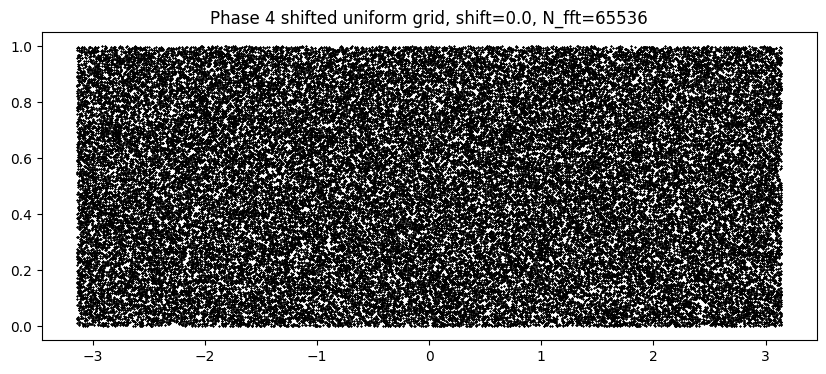

[1.63037249e-23 0.00000000e+00 1.63037249e-22 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.47546333e-02 1.05860744e-02
 3.42877657e-23 1.28749483e-18 1.16878648e+00 4.98000000e-01]


In [ ]:
# prepare shifted uniform full-period data for FFT Hilbert training
dataf, weighf, F0 = data_func_create_uniform_fft(
    N_fft,
    endpoint_strength=ENDPOINT_WEIGHT_STRENGTH,
    endpoint_width=ENDPOINT_WEIGHT_WIDTH,
    hotspot_centers=HOTSPOT_CENTERS,
    hotspot_strength=HOTSPOT_WEIGHT_STRENGTH,
    hotspot_width=HOTSPOT_WEIGHT_WIDTH,
    shifts=SHIFT_SCHEDULE,
)
data_z = dataf(keys[0], F0)
weigh = call_weighf(weighf, wp=1.0, data_z=data_z)
data = dwcombine(data_z, weigh, eta0, eta_beta)
data = add_loss_scales(data, beta0, include_df=TRAIN_DERIVATIVE_RESIDUAL)

x_c = data['col'][0]
x_d = data['grad'][0]

fig = plt.figure(figsize=(10, 4), dpi=100)
ax = plt.subplot(111)
ax.plot(x_c, random.uniform(keys[0], x_c.shape), 'kx', markersize=1, label='uniform FFT grid')
ax.set_title(f'Phase 4 shifted uniform grid, shift={dataf.current_shift}, N_fft={N_fft}')
plt.show()

predf = stwv_pred_create(lmt)
stwv_loss = loss_create(
    predf,
    cond,
    lamb0,
    beta0,
    lw,
    ew,
    train_df=TRAIN_DERIVATIVE_RESIDUAL,
)

stwv_loss.ref = stwv_loss(params, data)[0]
print(stwv_loss(params, data)[1])


In [ ]:
# ============================================================
# Phase 4 initial/base check on the same uniform FFT grid used in training.
# ============================================================

_x_chk = x_fft
_func = lambda z: predf(params, z)

_f_y = lambda z: _func(z)[:, 0:1]
_f_t1 = lambda z: _func(z)[:, 1:2]
_f_t2 = lambda z: _func(z)[:, 2:3]
_f_yx = lambda z: vectgrad(_f_y, z)[0]
_f_ysqx = lambda z: vectgrad(lambda w: _f_y(w) ** 2, z)[0]
_f_dt2 = lambda z: vectgrad(_f_t2, z)[0]


def _chk(xx):
    y_x, y = vectgrad(_f_y, xx)
    Hy_x = hptrans(xx, _f_yx)
    Hysq_x = hptrans(xx, _f_ysqx)
    dt1, t1 = vectgrad(_f_t1, xx)
    t2 = _f_t2(xx)
    Hdt2 = hptrans(xx, _f_dt2)
    S = g * y + g * 0.5 * Hysq_x + g * y * Hy_x + beta0**2 * (-dt1 + Hdt2)
    D = jnp.sqrt(y_x**2 + (1.0 + Hy_x) ** 2)
    return jnp.hstack([Hy_x, S, t2 - (1.0 + Hy_x) / D, t1 - y_x / D])

_P = _chk(_x_chk)
_Hy_x, _S, _e2, _e3 = _P[:, 0:1], _P[:, 1:2], _P[:, 2:3], _P[:, 3:4]

_rms = lambda lam: float(jnp.sqrt(jnp.mean((-lam**2 * _Hy_x + _S) ** 2)))
_lamb_fit = float(jnp.sqrt(jnp.sum(_Hy_x * _S) / jnp.sum(_Hy_x * _Hy_x)))

print(f'rms(e1) at lamb0    = {lamb0:.15f} : {_rms(lamb0):.3e}')
print(f'rms(e1) at best fit = {_lamb_fit:.15f} : {_rms(_lamb_fit):.3e}')
print(f'best fit - lamb0    = {_lamb_fit - lamb0:+.3e}')
print(f'max|e2| = {float(jnp.max(jnp.abs(_e2))):.3e}   max|e3| = {float(jnp.max(jnp.abs(_e3))):.3e}')


rms(e1) at lamb0    = 1.168786480600756 : 8.274e-13
rms(e1) at best fit = 1.168786480600774 : 8.271e-13
best fit - lamb0    = +1.821e-14
max|e2| = 2.147e-11   max|e3| = 1.700e-11


In [ ]:
"""Training using KFAC: Phase 4 fresh-frequency spectral polish."""
params, loss = kfac_optimizer(
    keys[2],
    stwv_loss,
    kfac_config,
    params,
    dataf,
    F0,
    epoch2,
    resample_every=SHIFT_RESAMPLE_EVERY,
    wp=1.0,
)

loss_all = np.array(loss)


Step: 50 | Loss: 1.37974909e-23 | Data: 0.00000000e+00 | Eqn: 1.37974909e-22 | Eqn_f: 3.427104056745e-23 | rel_f: +0.000e+00 | Eqn_df: 1.037038684853e-18 | lamb: 1.168786480600756 | beta: 0.498000000000 | Dp: 9.1385e-09
Step: 100 | Loss: 1.24999618e-23 | Data: 0.00000000e+00 | Eqn: 1.24999618e-22 | Eqn_f: 3.424110618140e-23 | rel_f: -8.735e-04 | Eqn_df: 9.075851160664e-19 | lamb: 1.168786480600756 | beta: 0.498000000000 | Dp: 8.2680e-09
Step: 150 | Loss: 1.23054247e-23 | Data: 0.00000000e+00 | Eqn: 1.23054247e-22 | Eqn_f: 3.423848214334e-23 | rel_f: -9.500e-04 | Eqn_df: 8.881576525361e-19 | lamb: 1.168786480600756 | beta: 0.498000000000 | Dp: 7.4805e-09
Step: 200 | Loss: 1.21725735e-23 | Data: 0.00000000e+00 | Eqn: 1.21725735e-22 | Eqn_f: 3.423828862419e-23 | rel_f: -9.557e-04 | Eqn_df: 8.748744654536e-19 | lamb: 1.168786480600756 | beta: 0.498000000000 | Dp: 6.7679e-09
Step: 250 | Loss: 1.19849945e-23 | Data: 0.00000000e+00 | Eqn: 1.19849945e-22 | Eqn_f: 3.424568815545e-23 | rel_f: -7

In [ ]:
# get the inferred lamb/beta from the same eta used during training
lamb = lamb0 + eta0 * jnp.tanh(params[-1])[0]
beta = beta0 + eta_beta * jnp.tanh(params[-2])[0]
print(lamb, beta)


# Saving the output

In [ ]:
# calculate the equation residual on the same one-period uniform FFT grid
f_y = lambda x: predf(params, x)
f_yx = lambda x: vectgrad(f_y, x)[0]

x_star = x_fft

y_x, y_values = vectgrad(f_y, x_star)
Hy_p = hptrans(x_star, f_y)
Hy_x = hptrans(x_star, f_yx)

f = stwv_gov_eqn(f_y, x_star, lamb, beta)
df = stwv_deri_eqn(f_y, x_star, lamb, beta)

validation_shifts = (0.0, 0.25, 0.5, 0.75)
validation_rows = []
print('\nvalidation residuals across shifted uniform grids')
print(f"{'shift':>8} {'e1 rms':>12} {'e2 rms':>12} {'e3 rms':>12} {'df rms':>12} {'max f':>12} {'max df':>12}")
for shift in validation_shifts:
    x_val = uniform_fft_grid(N_fft, shift=shift)
    f_val = stwv_gov_eqn(f_y, x_val, lamb, beta)
    df_val = stwv_deri_eqn(f_y, x_val, lamb, beta)
    e_rms = jnp.sqrt(jnp.mean(f_val ** 2, axis=0))
    df_rms = jnp.sqrt(jnp.mean(df_val ** 2))
    max_f = jnp.max(jnp.abs(f_val))
    max_df = jnp.max(jnp.abs(df_val))
    validation_rows.append(jnp.hstack([jnp.array([shift]), e_rms, jnp.array([df_rms, max_f, max_df])]))
    print(f"{shift:8.2f} {float(e_rms[0]):12.3e} {float(e_rms[1]):12.3e} {float(e_rms[2]):12.3e} {float(df_rms):12.3e} {float(max_f):12.3e} {float(max_df):12.3e}")
validation_stats = jnp.vstack(validation_rows)

ExpName = f"Wilton_phase4_fft_N={N_fft}_base_dfq={PHASE3_DFQ:.0f}_dfq4={dfq:.0f}_{RUN_TAG}_lamd={lamb:.4f}_beta={beta:.4f}_g={g:.1f}"

mdic = {
    'lamb': np.array(lamb),
    'beta': np.array(beta),
    'eta': np.array(eta0),
    'x': np.array(x_star),
    'y': np.array(y_values),
    'Hy': np.array(Hy_p),
    'Hy_x': np.array(Hy_x),
    'y_x': np.array(y_x),
    'f': np.array(f),
    'df': np.array(df),
    'validation_stats': np.array(validation_stats),
    'phase3_base_weights_name': np.array(PHASE3_WEIGHTS_NAME),
    'phase3_base_weights_url': np.array(PHASE3_WEIGHTS_URL),
    'phase3_dfq': np.array(PHASE3_DFQ),
    'phase3_epsilonp': np.array(PHASE3_EPSILONP),
    'phase4_dfq': np.array(dfq),
    'phase4_epsilonp': np.array(epsilonp),
    'endpoint_weight_strength': np.array(ENDPOINT_WEIGHT_STRENGTH),
    'hotspot_centers': np.array(HOTSPOT_CENTERS),
    'hotspot_weight_strength': np.array(HOTSPOT_WEIGHT_STRENGTH),
    'hotspot_weight_width': np.array(HOTSPOT_WEIGHT_WIDTH),
    'loss': loss_all,
}
FileName = ExpName + '.mat'

weights_path = str(rootdir.joinpath(ExpName + '_weights.pkl'))
with open(weights_path, 'wb') as f_out:
    pickle.dump(params, f_out)

checkpoint_path = str(rootdir.joinpath(ExpName + '_checkpoint.pkl'))
with open(checkpoint_path, 'wb') as f_out:
    pickle.dump({
        'kind': 'wilton_phase4_multifrequency_fft',
        'params': params,
        'phase3_params': phase3_params,
        'params0': params0,
        'lamb': lamb,
        'beta': beta,
        'lamb0': lamb0,
        'beta0': beta0,
        'eta0': eta0,
        'eta_beta': eta_beta,
        'epsilonp': epsilonp,
        'dfq': dfq,
        'phase3_weights_name': PHASE3_WEIGHTS_NAME,
        'phase3_weights_url': PHASE3_WEIGHTS_URL,
        'phase3_lamb': PHASE3_LAMB,
        'phase3_dfq': PHASE3_DFQ,
        'phase3_epsilonp': PHASE3_EPSILONP,
        'N_fft': N_fft,
        'run_tag': RUN_TAG,
        'endpoint_weight_strength': ENDPOINT_WEIGHT_STRENGTH,
        'endpoint_weight_width': ENDPOINT_WEIGHT_WIDTH,
        'hotspot_centers': HOTSPOT_CENTERS,
        'hotspot_weight_strength': HOTSPOT_WEIGHT_STRENGTH,
        'hotspot_weight_width': HOTSPOT_WEIGHT_WIDTH,
        'shift_schedule': SHIFT_SCHEDULE,
        'shift_resample_every': SHIFT_RESAMPLE_EVERY,
        'validation_stats': validation_stats,
        'loss': loss_all,
    }, f_out)

print('weights:', weights_path)
print('checkpoint:', checkpoint_path)


In [ ]:
FilePath = str(rootdir.joinpath(FileName))
savemat(FilePath, mdic)
print('wrote', FilePath)


In [ ]:
# ============================================================
# Optional standalone stage-1 sanity check on the Phase 2 FFT grid.
# FFT Hilbert must see the whole one-period uniform grid at once.
# ============================================================
import requests as _rq

_s1_url = ("https://raw.githubusercontent.com/michalshavitNYU/Waves/main/"
           "StokesWave_lamd%3D1.1688_beta%3D0.4980_g%3D1.0_weights.pkl")
_s1_lamb, _s1_beta, _s1_sclp = 1.168786478283629, 0.4980, 0.27

_r = _rq.get(_s1_url, timeout=60); assert _r.status_code == 200, _r.status_code
open("_s1_check.pkl", "wb").write(_r.content)
_s1_p = pickle.load(open("_s1_check.pkl", "rb"))
print("len =", len(_s1_p), " beta_mod =", _s1_p[-2], " lamb_mod =", _s1_p[-1])

_s1_lmt = jnp.array([jnp.pi, _s1_sclp])
_s1_f  = lambda z: _s1_sclp * neural_net_even(_s1_p[0:3], z, _s1_lmt)
_s1_y  = lambda z: _s1_f(z)[:, 0:1]
_s1_t1 = lambda z: _s1_f(z)[:, 1:2]
_s1_t2 = lambda z: _s1_f(z)[:, 2:3]

def _s1_res(xx):
    y_x, y = vectgrad(_s1_y, xx)
    Hy_x   = hptrans(xx, lambda z: vectgrad(_s1_y, z)[0])
    Hysq_x = hptrans(xx, lambda z: vectgrad(lambda w: _s1_y(w)**2, z)[0])
    dt1, t1 = vectgrad(_s1_t1, xx)
    t2 = _s1_t2(xx)
    Hdt2 = hptrans(xx, lambda z: vectgrad(_s1_t2, z)[0])
    e1 = (-_s1_lamb**2 * Hy_x + g*y + g*0.5*Hysq_x + g*y*Hy_x
          + _s1_beta**2 * (-dt1 + Hdt2))
    D = jnp.sqrt(y_x**2 + (1.0 + Hy_x)**2)
    return jnp.hstack([e1, t2 - (1.0 + Hy_x)/D, t1 - y_x/D])

_s1_x = x_fft
_s1_R = _s1_res(_s1_x)

print(f"\n{'':<6}{'mean_abs':>12}{'rms':>12}{'max_abs':>12}")
for _j, _nm in enumerate(["e1", "e2", "e3"]):
    _r_ = _s1_R[:, _j]
    print(f"{_nm:<6}{float(jnp.mean(jnp.abs(_r_))):>12.3e}"
          f"{float(jnp.sqrt(jnp.mean(_r_**2))):>12.3e}"
          f"{float(jnp.max(jnp.abs(_r_))):>12.3e}")

print("\nThis check uses the Phase 2 FFT Hilbert grid, so values need not match the old nonuniform-Hilbert sanity check exactly.")

In [ ]:
print(lamb, beta)

In [ ]:
# Optional Colab helper: save through /content first if direct Drive writes are slow.
import shutil, os

FilePath = str(rootdir.joinpath(FileName))
tmp_path = '/content/' + FileName

savemat(tmp_path, mdic)
shutil.copy(tmp_path, FilePath)
print('wrote', FilePath, os.path.getsize(FilePath) / 1e6, 'MB')
